In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [42]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler

In [56]:
Ytrain  = pd.read_pickle('../data/ytrain.pkl')
Ytest   = pd.read_pickle('../data/ytest.pkl')

Xtrain  = pd.read_pickle('../data/xtrain.pkl')
Xtest   = pd.read_pickle('../data/xtest.pkl')

In [60]:
scaler = MinMaxScaler()


Xtrain_norm = scaler.fit_transform(Xtrain)
Xtest_norm = scaler.fit_transform(Xtest)

Ytrain_dummy = pd.get_dummies(Ytrain, dtype=np.float32)
Ytest_dummy = pd.get_dummies(Ytest, dtype=np.float32)

#tf.keras.utils.to_categorical também faz a mesma coisa
#Ytrain_dummy2 = tf.keras.utils.to_categorical(Ytrain, num_classes=4)

In [75]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[21]),
    keras.layers.Dense(200, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(3, activation="softmax")
])

/home/rodrigo/.local/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [76]:
print(model.summary())

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 200)            │         4,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,803 (96.89 KB)

 Trainable params: 24,803 (96.89 KB)

 Non-trainable params: 0 (0.00 B)

None


In [77]:
model.compile(loss="categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [78]:
history = model.fit(Xtrain_norm, Ytrain_dummy, epochs=200, validation_split=0.1)

Epoch 1/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6335 - loss: 0.9487 - val_accuracy: 0.7812 - val_loss: 0.6928
Epoch 2/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7683 - loss: 0.7007 - val_accuracy: 0.7812 - val_loss: 0.6419
Epoch 3/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7790 - loss: 0.6516 - val_accuracy: 0.7812 - val_loss: 0.6226
Epoch 4/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7889 - loss: 0.6138 - val_accuracy: 0.7812 - val_loss: 0.6055
Epoch 5/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7908 - loss: 0.5949 - val_accuracy: 0.7812 - val_loss: 0.5883
Epoch 6/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7762 - loss: 0.6084 - val_accuracy: 0.7812 - val_loss: 0.5710
Epoch 7/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7960 - loss: 0.5598 - val_accuracy: 0.7812 - val_loss: 0.5544
Epoch 8/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7926 - loss: 0.5412 - val_accuracy: 0.7812 - v

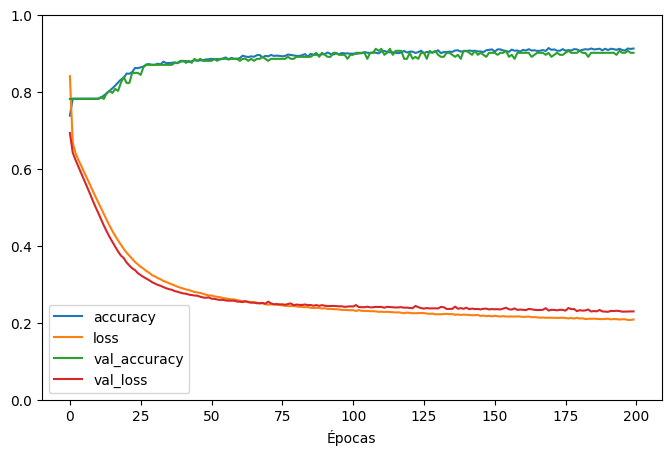

In [80]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.gca().set_ylim(0, 1)
plt.xlabel("Épocas")
plt.savefig('../results/treinoRedeNeuralComScaler.png')
plt.show()

In [81]:
model.evaluate(Xtest_norm, Ytest_dummy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8737 - loss: 0.2562 


[0.30212387442588806, 0.8685445785522461]

In [83]:
ypred = model.predict(Xtest)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [88]:
from sklearn.metrics import classification_report, confusion_matrix

In [108]:
fresults = open('../results/classificationMetricsRedeNeura.txt', 'w+')
print(classification_report(Ytest_dummy, ypred))
fresults.write(classification_report(Ytest_dummy, ypred))

fresults.close()


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       159
           1       0.17      1.00      0.29        36
           2       1.00      0.11      0.20        18

   micro avg       0.18      0.18      0.18       213
   macro avg       0.39      0.37      0.16       213
weighted avg       0.11      0.18      0.07       213
 samples avg       0.18      0.18      0.18       213



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


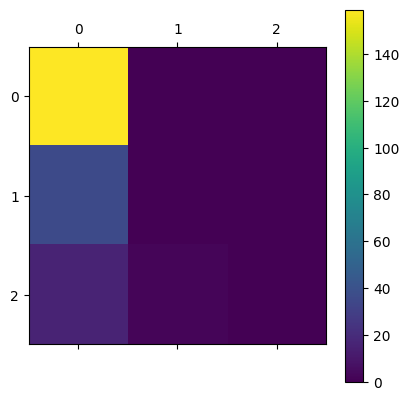

In [106]:
rounded_labels=np.argmax(ypred, axis=1)

conf_matrix = confusion_matrix(Ytest, rounded_labels)
plt.matshow(conf_matrix)
plt.colorbar()
plt.savefig('../results/ConfMatrixRedeNeural.png')
plt.show()

<Figure size 800x600 with 0 Axes>

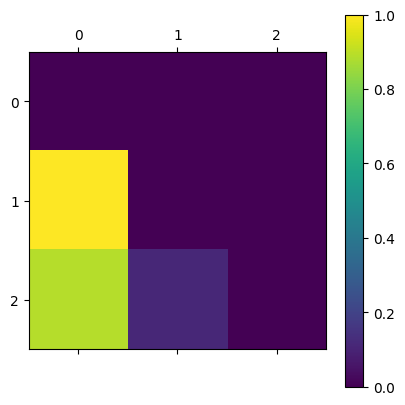

In [105]:
row_sums = conf_matrix.sum(axis=1, keepdims=True)
norm_conf_mx = conf_matrix / row_sums
np.fill_diagonal(norm_conf_mx, 0)
plt.figure(figsize=(8,6))
plt.matshow(norm_conf_mx)
plt.colorbar()
plt.savefig('../results/relativeConfMatrixRedeNeural.png')
plt.show()